### Importing Libraries

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from scipy.stats import ks_2samp

### Loading Dataset

In [154]:
df = pd.read_csv("diabetes .csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [155]:
print(df.shape)

(768, 9)


### Separate Baseline and Streaming Data

In [156]:
baseline = df.iloc[:500]
stream = df.iloc[500:]

### Split Features and Target

In [157]:
X_base = baseline.drop("Outcome", axis=1)

y_base = baseline["Outcome"]

### Train Simple ML Model

In [158]:
model = LogisticRegression(max_iter=1000)

model.fit(X_base, y_base)

LogisticRegression(max_iter=1000)

### Compute Baseline Confidence

In [159]:
probs = model.predict_proba(X_base)

confidence = probs.max(axis=1)

mu_0 = confidence.mean()

print(mu_0)

0.7622208414327672


### Create Sliding Window

In [160]:
window_size = 20

### Take First Stream Window

In [161]:
window = stream.iloc[:window_size]

### Current Window Confidence

In [162]:
X_window = window.drop("Outcome", axis=1)

probs_window = model.predict_proba(X_window)

conf_window = probs_window.max(axis=1)

mu_t = conf_window.mean()

print(mu_t)

0.77853033126396


### Confidence Drift

In [163]:
confidence_drift = abs(mu_t - mu_0)

print(confidence_drift)

0.016309489831192736


### PSI Function

In [164]:
def calculate_psi(expected, actual, bins=10):

    breakpoints = np.linspace(0, 100, bins + 1)

    expected_bins = np.percentile(expected, breakpoints)

    expected_counts = np.histogram(expected, bins=expected_bins)[0]
    actual_counts = np.histogram(actual, bins=expected_bins)[0]

    expected_ratios = expected_counts / len(expected)
    actual_ratios = actual_counts / len(actual)

    psi = np.sum(
        (expected_ratios - actual_ratios)
        * np.log(
            (expected_ratios + 1e-6)
            / (actual_ratios + 1e-6)
        )
    )

    return psi

### Calculate PSI

In [165]:
psi_score = calculate_psi(
    confidence,
    conf_window
)

print(psi_score)

0.2414132868939146


### KS Test

In [166]:
ks_score, p_value = ks_2samp(
    confidence,
    conf_window
)

print(ks_score)

0.164


### Stability Score

In [167]:
prev_mu = mu_0

stability = abs(mu_t - prev_mu)

print(stability)

0.016309489831192736


### Final HDSM Score

In [168]:
alpha = 0.3
beta = 0.3
gamma = 0.2
lam = 0.2

D_t = (
    alpha * confidence_drift
    + beta * psi_score
    + gamma * ks_score
    + lam * stability
)

print(D_t)

0.11337873098377074


### Drift Detection

In [169]:
threshold = 0.2

if D_t > threshold:
    print("Drift Detected")
else:
    print("No Drift")

No Drift


### Create Empty Lists

In [170]:
drift_scores = []

psi_list = []

ks_list = []

stability_list = []

confidence_list = []

### Initialize Previous Values

In [171]:
prev_mu = mu_0

prev_Dt = 0

In [172]:
window_size=20

### Full Sliding Window Loop

In [173]:
for i in range(0, len(stream), window_size):

    window = stream.iloc[i:i+window_size]

    if len(window) < window_size:
        continue
    
    print("Processing Window:", i)

    X_window = window.drop("Outcome", axis=1)

    probs_window = model.predict_proba(X_window)

    conf_window = probs_window.max(axis=1)

    mu_t = conf_window.mean()

    confidence_drift = abs(mu_t - mu_0)

    psi_score = calculate_psi(
        confidence,
        conf_window
    )

    ks_score, p_value = ks_2samp(
        confidence,
        conf_window
    )

    stability = abs(mu_t - prev_mu)

    D_t = (
        alpha * confidence_drift
        + beta * psi_score
        + gamma * ks_score
        + lam * stability
    )

    drift_speed = D_t - prev_Dt

    drift_scores.append(D_t)

    psi_list.append(psi_score)

    ks_list.append(ks_score)

    stability_list.append(stability)

    confidence_list.append(mu_t)

    prev_mu = mu_t

    prev_Dt = D_t

Processing Window: 0
Processing Window: 20
Processing Window: 40
Processing Window: 60
Processing Window: 80
Processing Window: 100
Processing Window: 120
Processing Window: 140
Processing Window: 160
Processing Window: 180
Processing Window: 200
Processing Window: 220
Processing Window: 240


In [174]:
print(len(drift_scores))

print(len(psi_list))

print(len(confidence_list))

13
13
13


In [175]:
print(len(stream))

268


In [176]:
print(stream.shape)

(268, 9)


### Drift Detection Alert

In [177]:
if D_t > threshold:
    print(f"Drift detected at window {i}")

Drift detected at window 260


In [178]:
print(drift_scores)

print(len(drift_scores))

[0.11337873098377074, 0.7964757940254944, 0.09564726767464549, 1.1989256561547192, 0.7831004681774194, 0.4425922460294716, 0.5550897615577172, 0.4778528847803606, 0.13961928815177135, 0.42291890388373027, 0.8188539940324432, 0.8038557568597196, 0.8344987590923113]
13


### Update Previous Values

In [179]:
prev_mu = mu_t

prev_Dt = D_t

# visualisation

### Plot Drift Scores

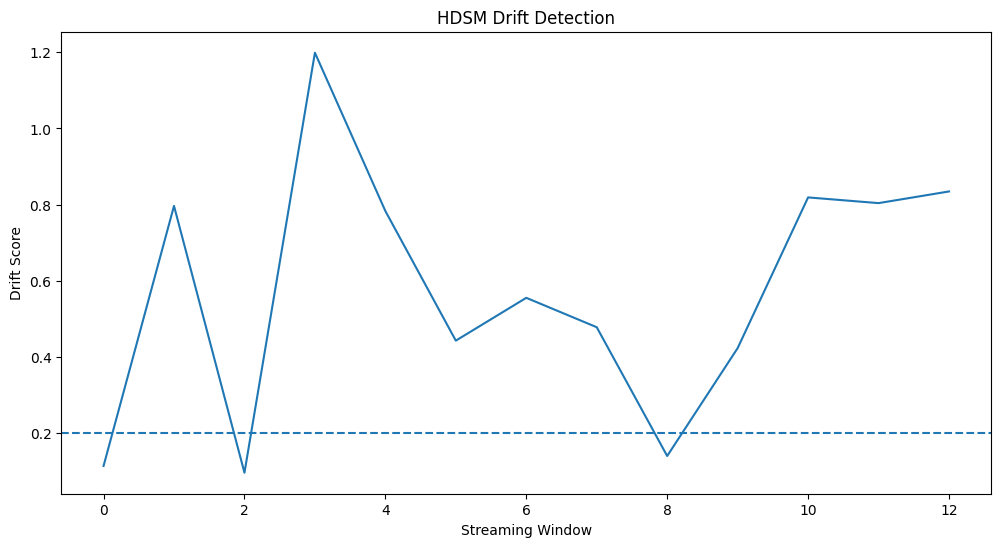

In [180]:
plt.figure(figsize=(12,6))

plt.plot(drift_scores)

plt.axhline(
    y=threshold,
    linestyle='--'
)

plt.title("HDSM Drift Detection")

plt.xlabel("Streaming Window")

plt.ylabel("Drift Score")

plt.show()

### Plot PSI and KS

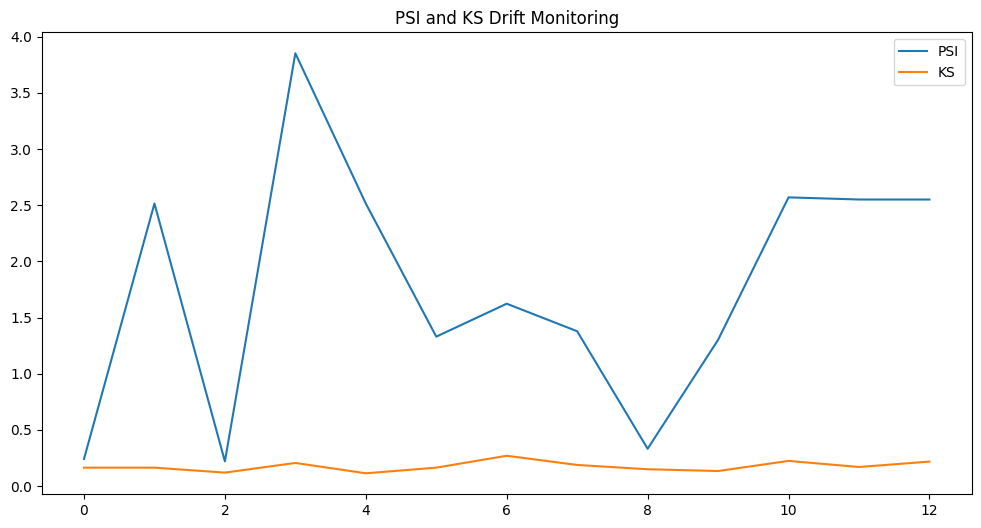

In [181]:
plt.figure(figsize=(12,6))

plt.plot(psi_list, label="PSI")

plt.plot(ks_list, label="KS")

plt.legend()

plt.title("PSI and KS Drift Monitoring")

plt.show()

### Plot Confidence Changes

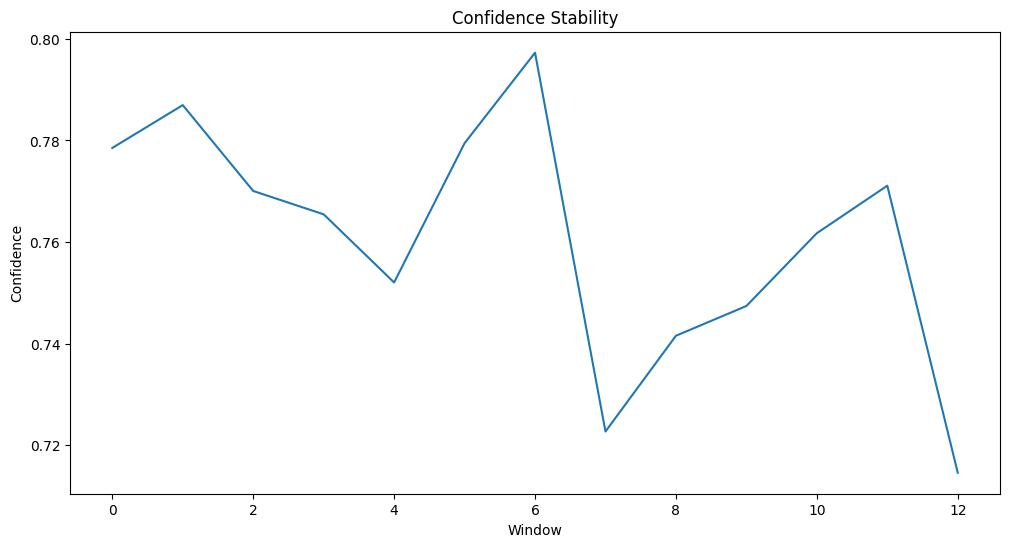

In [182]:
plt.figure(figsize=(12,6))

plt.plot(confidence_list)

plt.title("Confidence Stability")

plt.xlabel("Window")

plt.ylabel("Confidence")

plt.show()

### Artificial Drift Injection

In [183]:
stream_drifted = stream.copy()

stream_drifted["Glucose"] += 40

In [184]:
drift_scores_drifted = []

psi_list_drifted = []

ks_list_drifted = []

stability_list_drifted = []

confidence_list_drifted = []

prev_mu = mu_0

prev_Dt = 0

for i in range(0, len(stream_drifted), window_size):

    window = stream_drifted.iloc[i:i+window_size]

    if len(window) < window_size:
        continue

    print("Processing Drifted Window:", i)

    X_window = window.drop("Outcome", axis=1)

    probs_window = model.predict_proba(X_window)

    conf_window = probs_window.max(axis=1)

    mu_t = conf_window.mean()

    confidence_drift = abs(mu_t - mu_0)

    psi_score = calculate_psi(
        confidence,
        conf_window
    )

    ks_score, p_value = ks_2samp(
        confidence,
        conf_window
    )

    stability = abs(mu_t - prev_mu)

    D_t = (
        alpha * confidence_drift
        + beta * psi_score
        + gamma * ks_score
        + lam * stability
    )

    drift_scores_drifted.append(D_t)

    psi_list_drifted.append(psi_score)

    ks_list_drifted.append(ks_score)

    stability_list_drifted.append(stability)

    confidence_list_drifted.append(mu_t)

    prev_mu = mu_t

    prev_Dt = D_t

Processing Drifted Window: 0
Processing Drifted Window: 20
Processing Drifted Window: 40
Processing Drifted Window: 60
Processing Drifted Window: 80
Processing Drifted Window: 100
Processing Drifted Window: 120
Processing Drifted Window: 140
Processing Drifted Window: 160
Processing Drifted Window: 180
Processing Drifted Window: 200
Processing Drifted Window: 220
Processing Drifted Window: 240


In [185]:
drift_scores_drifted

[0.9136604485407158,
 1.1613657512156133,
 0.5118059026577197,
 1.2075000320023386,
 0.4597700973938391,
 0.47180568803505224,
 0.9994500700534354,
 1.1968922111738842,
 0.12391962463926852,
 0.5059928353256543,
 0.91527821354124,
 1.6875247972162475,
 0.43782516180238973]

In [186]:
print(len(drift_scores_drifted))

13


### Comparison Graph

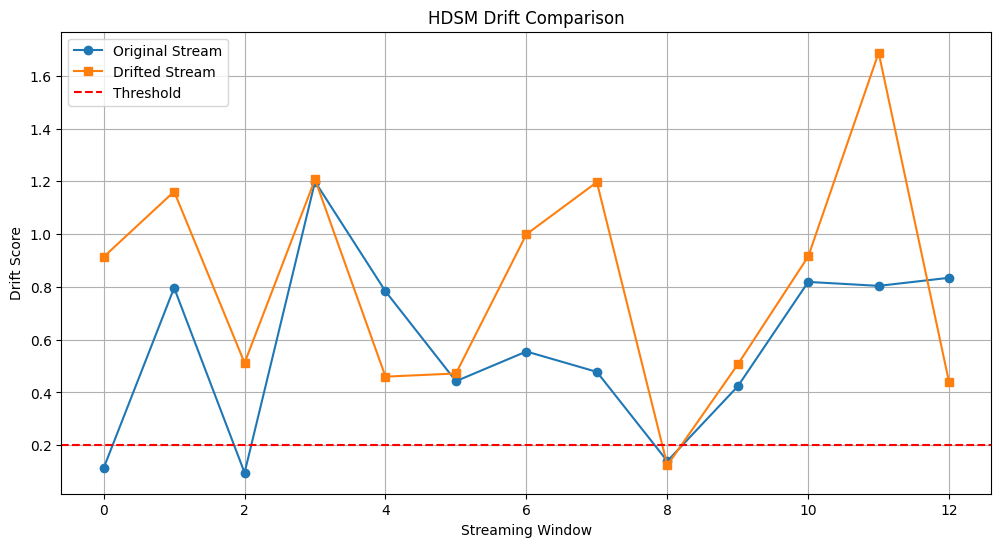

In [187]:
plt.figure(figsize=(12,6))

plt.plot(
    drift_scores,
    marker='o',
    label="Original Stream"
)

plt.plot(
    drift_scores_drifted,
    marker='s',
    label="Drifted Stream"
)

plt.axhline(
    y=threshold,
    color='r',
    linestyle='--',
    label='Threshold'
)

plt.title("HDSM Drift Comparison")

plt.xlabel("Streaming Window")

plt.ylabel("Drift Score")

plt.legend()

plt.grid(True)

plt.show()

### Alert + Recommendation System

In [188]:
for score in drift_scores_drifted:

    if score < 0.2:

        print("✅ Stable Stream")

    elif score < 0.5:

        print("⚠ Moderate Drift Detected")
        print("Recommendation: Monitor Carefully")

    else:

        print("🚨 Severe Drift Detected")
        print("Recommendation: Retraining Suggested")

🚨 Severe Drift Detected
Recommendation: Retraining Suggested
🚨 Severe Drift Detected
Recommendation: Retraining Suggested
🚨 Severe Drift Detected
Recommendation: Retraining Suggested
🚨 Severe Drift Detected
Recommendation: Retraining Suggested
⚠ Moderate Drift Detected
Recommendation: Monitor Carefully
⚠ Moderate Drift Detected
Recommendation: Monitor Carefully
🚨 Severe Drift Detected
Recommendation: Retraining Suggested
🚨 Severe Drift Detected
Recommendation: Retraining Suggested
✅ Stable Stream
🚨 Severe Drift Detected
Recommendation: Retraining Suggested
🚨 Severe Drift Detected
Recommendation: Retraining Suggested
🚨 Severe Drift Detected
Recommendation: Retraining Suggested
⚠ Moderate Drift Detected
Recommendation: Monitor Carefully


### Drift severity visualization

In [189]:
statuses = []

for score in drift_scores_drifted:

    if score < 0.2:

        statuses.append("Stable")

    elif score < 0.5:

        statuses.append("Moderate Drift")

    else:

        statuses.append("Severe Drift")

print(statuses)

['Severe Drift', 'Severe Drift', 'Severe Drift', 'Severe Drift', 'Moderate Drift', 'Moderate Drift', 'Severe Drift', 'Severe Drift', 'Stable', 'Severe Drift', 'Severe Drift', 'Severe Drift', 'Moderate Drift']
